In [ ]:
#Imports
import numpy as np
import pandas as pd
import datetime as dt
import math
import seaborn as sns
from numpy.random import seed

import io
import gc

from scipy.stats import norm
from scipy.sparse import data
from scipy.optimize import brentq
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
#Seed
np.random.seed(101)

#Fixed Parameters
S0 = 200  # initial spot for IV and local vol calibration
r = 0.02 # risk-free rate
T = 1 # 1 year time horizon

In [ ]:
#Upload MXXX_XXXX_dataset.xlsx
from google.colab import files
uploaded = files.upload()
# Transfer excel file to DataFrame
option_prices = pd.read_excel('MXXXXXXX_dataset.xlsx')

Saving MANG3117_common_dataset.xlsx to MANG3117_common_dataset (1).xlsx


BSM PRICING: General BSM pricing function for both call and puts. ".lower()" allows for global discrepancies between naming

In [ ]:
#BSM pricing formula
def black_scholes_price(S, K, T, r, sigma, option_type):
    # Invalid case
    if T < 0 or sigma <= 0:
        return np.nan

    # T=0: intrinsic value only
    if T == 0:
        if option_type.lower() == 'call':
            return max(S - K, 0)
        elif option_type.lower() == 'put':
            return max(K - S, 0)
        else:
            raise ValueError("option_type must be 'call' or 'put'")

    # T>0: intrinsic value + time value
    d1 = (np.log(S / K) + ((r + 0.5 * sigma**2) * T)) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))
    PV_K = K * np.exp(-r * T)

    if option_type.lower() == 'call':
        price = (S * norm.cdf(d1)) - (PV_K * norm.cdf(d2))
    elif option_type.lower() == 'put':
        price = (PV_K * norm.cdf(-d2)) - (S * norm.cdf(-d1))
    else:
        raise ValueError("Invalid option_type")

    return price

**IMPLIED VOLATILITY:** IV function, application Orinoco option data and plotting surfaces for calls, puts and both

In [ ]:
#Implied Volatility Function
def implied_volatility_black_scholes(S, K, T, r, option_type, market_price, low_vol=1e-6, high_vol=5.0, tol=1e-5):
    if T <= 0:
        return np.nan

    # Find error between BSM price and market price
    def objective_function(sigma):
        if sigma <= 0:
            return np.nan
        return black_scholes_price(S, K, T, r, sigma, option_type) - market_price

    try:
        f_low = objective_function(low_vol)
        f_high = objective_function(high_vol)

        # If extreme values share same sign:
        if f_low * f_high >= 0:
          # BSM price is outside range
          # Check if extremes are within tolerance level:
            if abs(market_price - black_scholes_price(S, K, T, r, low_vol, option_type)) < tol:
                 return low_vol
            elif abs(market_price - black_scholes_price(S, K, T, r, high_vol, option_type)) < tol:
                 return high_vol
            else: #If not:
                return np.nan

        #Optimised IV
        implied_vol = brentq(objective_function, low_vol, high_vol, xtol=tol)
        return implied_vol

    except Exception:
      return np.nan

In [ ]:
#Apply IV function to each row of the DataFrame
option_prices['Implied_Volatility'] = option_prices.apply(
    lambda row: implied_volatility_black_scholes(
        S=S0,
        K=row['Strike'],
        T=row['Maturity'],
        r=r,
        option_type=row['Type'],
        market_price=row['Price']
    ),
    axis=1
)

implied_vol_array = option_prices[['Maturity', 'Strike', 'Implied_Volatility']].to_records(index=False)

# Separate DataFrame into individual DataFrames for calls and puts
calls = option_prices[option_prices['Type'] == "call"]
puts = option_prices[option_prices['Type'] == "put"]

AttributeError: 'Series' object has no attribute 'lower'

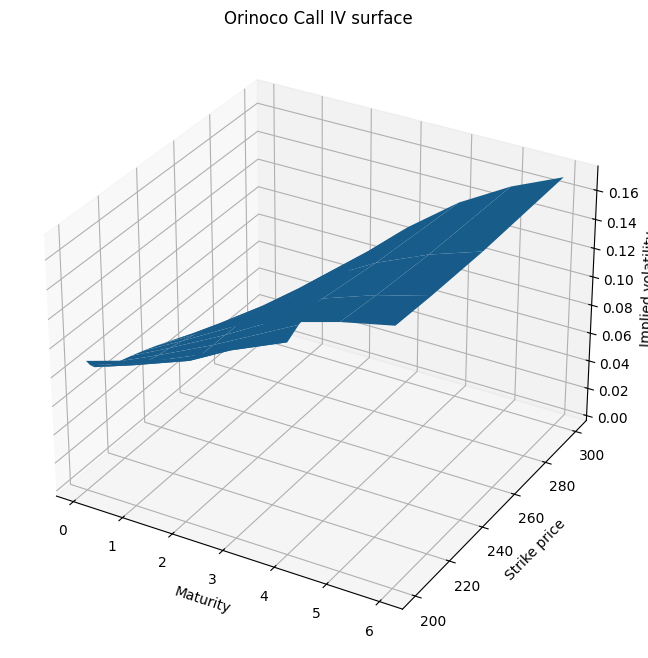

In [ ]:
#Display the Call IV Surface
call_surface = (calls.pivot_table(
    values='Implied_Volatility',
    index='Strike',
    columns='Maturity'
    ).dropna()
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#Axes values from call dataframe
x, y, z = call_surface.columns.values, call_surface.index.values, call_surface.values
#Coordinate matrices from coordinate vectors
X, Y = np.meshgrid(x, y)

#Labelling
ax.set_xlabel('Maturity')
ax.set_ylabel('Strike price')
ax.set_zlabel('Implied volatility')
ax.set_title('Orinoco Call IV surface')

ax.plot_surface(X, Y, z)
plt.show()

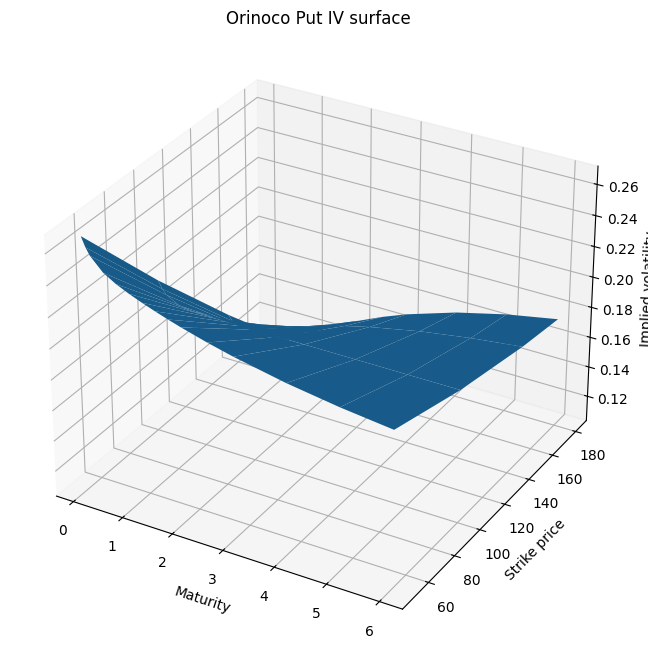

In [ ]:
#Display the Put IV Surface
put_surface = (puts.pivot_table(
    values='Implied_Volatility',
    index='Strike',
    columns='Maturity'
    ).dropna()
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Axes values from put dataframe
x, y, z = put_surface.columns.values, put_surface.index.values, put_surface.values
# Coordinate matrices from coordinate vectors
X, Y = np.meshgrid(x, y)

# Labelling
ax.set_xlabel('Maturity')
ax.set_ylabel('Strike price')
ax.set_zlabel('Implied volatility')
ax.set_title('Orinoco Put IV surface')

ax.plot_surface(X, Y, z)
plt.show()

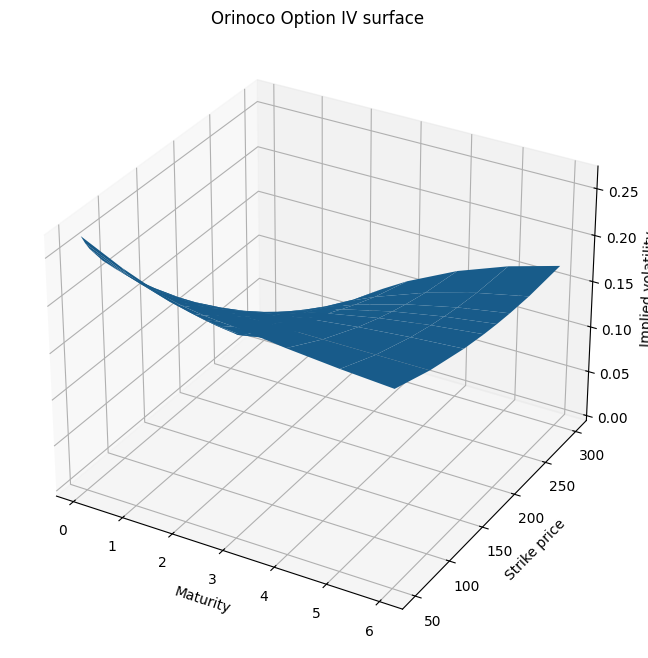

In [ ]:
#IV surface for all options, combined
options_surface = (option_prices.pivot_table(
    values='Implied_Volatility',
    index='Strike',
    columns='Maturity'
    ).dropna()
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Axes values from put dataframe
x, y, z = options_surface.columns.values, options_surface.index.values, options_surface.values
# Coordinate matrices from coordinate vectors
X, Y = np.meshgrid(x, y)

# Labelling
ax.set_xlabel('Maturity')
ax.set_ylabel('Strike price')
ax.set_zlabel('Implied volatility')
ax.set_title('Orinoco Option IV surface')

ax.plot_surface(X, Y, z)
plt.show()

**LOCAL VOLATILITY MODEL:** Now we can use the IV surface to calibrate a quadratic local volatility model.

In [ ]:
#Quadratic local vol calibration functions
market_data = implied_vol_array

def quadratic_vol(t, S, S0, p): # Quadratic local volatility function
  a_t = p[1] + (p[0] - p[1]) * np.exp(-p[2] * t)
  b_t = p[3] * np.exp(-p[4] * t)
  c_t = p[5] * np.exp(-p[6] * t)

  vol = a_t + b_t * (S - S0) + c_t * (S - S0)**2
  return np.maximum(vol, 0.01) # Floor to prevent negative volatility

def objective_local(p): # Error between model vol and market derived vol
  error = 0

  for t, K, mkt_vol in market_data:
    model_vol = quadratic_vol(t, K, S0, p)
    error += (model_vol - mkt_vol)**2

  return error

In [ ]:
#Local vol model calibration
initial_guess = [0.1, 0.2, 0.5, -0.005, 1.0, 0.0002, 1.0]
bounds = [
    (0.05, 0.8), (0.05, 0.8), (0.01, 5.0),
    (-0.1, 0.1), (0.1, 10.0),
    (0, 0.01), (0.1, 10.0)
]

result = minimize(
    objective_local,
    initial_guess,
    bounds=bounds,
    method = 'L-BFGS-B'
)

if result.success:
  print("Calibration Successful")
  print(f"Optimised Parameters: {result.x}")
else:
  print("Calibration Failed: ", result.message)

parameter_values = result.x

Calibration Successful
Optimised Parameters: [ 7.52788040e-02  2.01413792e-01  2.57575181e-01 -1.11003782e-03
  3.26199415e-01  1.16612104e-06  3.26196875e-01]


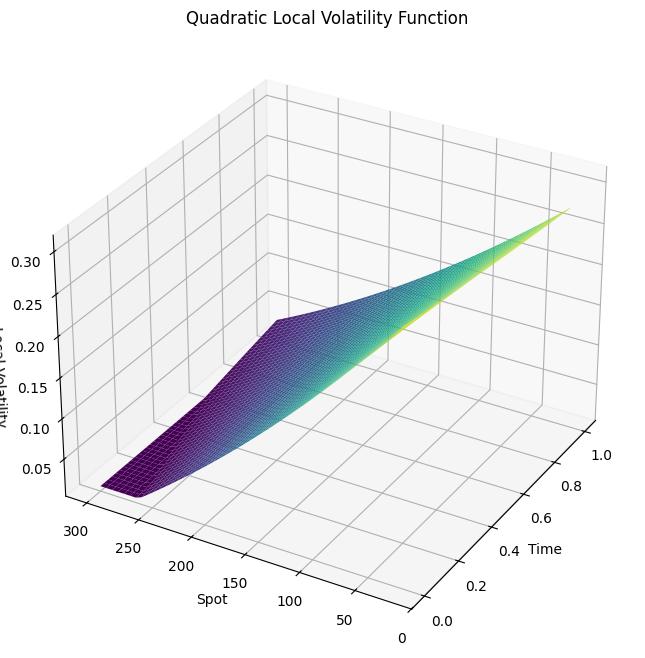

In [ ]:
#Plotting Local Volatility

# Define ranges for t and S
maturities = np.linspace(0, T, 50)
strikes = np.linspace(S0 * 0.1, S0 * 1.5, 50)

# Create a meshgrid
maturity_mesh, strikes_mesh = np.meshgrid(maturities, strikes)

# Calculate the local volatility surface using quadratic_vol
vol_surface = np.array([[quadratic_vol(t, s, 200, parameter_values) for t in maturities] for s in strikes])

# Create 3D plot
fig_quad = plt.figure(figsize=(12, 8))
ax_quad = fig_quad.add_subplot(111, projection='3d')

ax_quad.plot_surface(maturity_mesh, strikes_mesh, vol_surface, cmap='viridis')

ax_quad.view_init(elev=30, azim=210)

ax_quad.set_xlabel('Time')
ax_quad.set_ylabel('Spot')
ax_quad.set_zlabel('Local Volatility')
ax_quad.set_title('Quadratic Local Volatility Function')

plt.show()

In [ ]:
#Spot price evolution from local vol model
def sim_multi_path(S0, g, T, dt, params, n_paths):
  n_steps = int(T / dt) #Trading days
  S_paths = np.zeros((n_steps+1, n_paths))
  S_paths[0, :] = S0 #Start at S0

  # Calculate log price
  ln_S_current = np.full(n_paths, np.log(S0))

  for t_step in range(n_steps):
    current_S = np.exp(ln_S_current)
    vol = quadratic_vol(t_step * dt, current_S, S0, params)
    # Brownian motion
    noise = np.random.normal(0, np.sqrt(dt), n_paths)
    # Update price through Ito's Lemma
    ln_S_current += (g - 0.5 *vol**2) * dt + vol * noise
    # Convert back to normal prices
    S_paths[t_step + 1, :] = np.exp(ln_S_current)

  return S_paths

In [ ]:
#Fixed parameters for Monte Carlo simulation
dt = 1/252 #Daily time step

accum_factor = np.exp(r*1) # FV factor

n_paths = 100000 # Number of price simulations

book_S0 = 211.005714143339 # Initial spot for our simulation

drift = 0.05 # Fixed drift of 5%

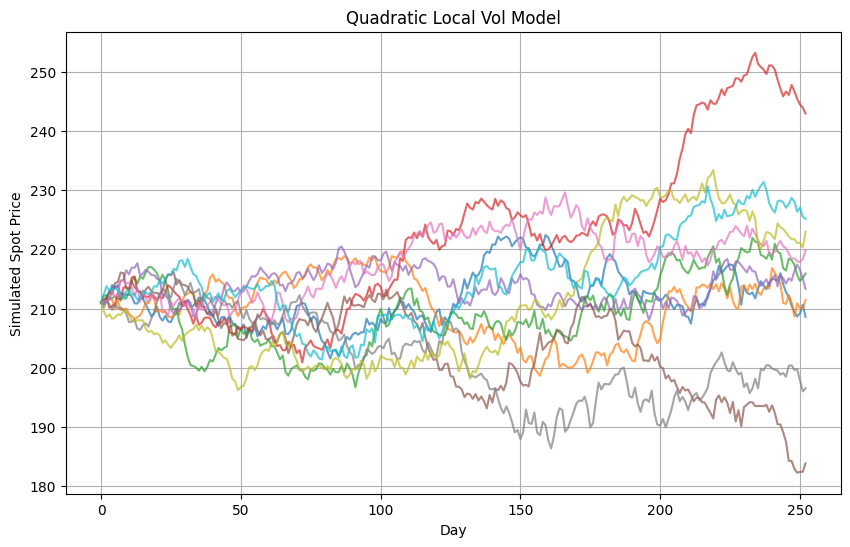

In [ ]:
#Simulate n_paths
paths = sim_multi_path(book_S0, drift, T, dt, parameter_values, n_paths)
# Plot 10 paths
plt.figure(figsize=(10, 6))
for i in range(min(10, n_paths)):
  plt.plot(paths[:, i], alpha=0.7)
# Labelling
plt.title("Quadratic Local Vol Model")
plt.xlabel("Day")
plt.ylabel("Simulated Spot Price")
plt.grid(True)
plt.show()

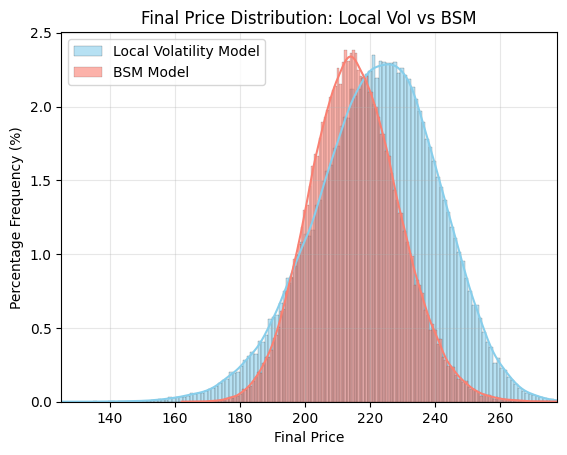

333

In [ ]:
#Price Distribution Histogram
final_spot = paths[-1, :] #Final spots based on local vol model
sigma_bsm = quadratic_vol(0, book_S0, S0, parameter_values)

# Same simulation using BSM + noise
def BSM_scenarios(N, S, g, T, sigma):
  log_returns = np.random.normal((g-0.5*sigma**2)*T, sigma*np.sqrt(T), size=N)
  return S*np.exp(log_returns)

BSM_prices = BSM_scenarios(n_paths, book_S0, r, T, sigma_bsm)

max_price = max(np.percentile(final_spot, 99.99), np.percentile(BSM_prices, 99.99))

# Local Vol Model Histogram
sns.histplot(final_spot, stat='percent', color='skyblue', label='Local Volatility Model',
             kde=True, alpha=0.6, binrange=(0, max_price))

# BSM Model Histogram
sns.histplot(BSM_prices, stat='percent', color='salmon', label='BSM Model',
             kde=True, alpha=0.6, binrange=(0, max_price))
plt.title('Final Price Distribution: Local Vol vs BSM')
plt.xlabel('Final Price')
plt.ylabel('Percentage Frequency (%)')
plt.legend()
plt.grid(True,alpha=0.3)
plt.xlim(125, max_price)

plt.show()

# Reduce memory usage
del paths, final_spot
gc.collect()

**PAYOFFS:** Now we have calibrated the volatility dynamics on Orinoco, we can move onto using our personalised book to find payoff and P&L scenarios

In [ ]:
#Upload personalised_data_33732477.xlsx
from google.colab import files
uploaded = files.upload()

# Book initialisation
book = pd.read_excel('personalised_data_33732477.xlsx')
n_opts = len(book)

initial_prices = np.array([
    black_scholes_price(book_S0, row['Strike'], row['Term (years)'],
      r, quadratic_vol(0, book_S0, S0, parameter_values), row['Type'])
    for _, row in book.iterrows()
])

# The number of contracts held in each option
position = np.zeros(4)
for i, (option, row) in enumerate(book.iterrows()):
  position[i] = row['Notional ($m)'] * 1000000 / book_S0

Saving personalised_data_33732477.xlsx to personalised_data_33732477 (1).xlsx


In [ ]:
#Book info
print(f"Long put  : Contracts: {round(position[0], 2)}, Initial Price: {initial_prices[0]} \nLong call : Contracts: {position[1]}, Initial Price: {initial_prices[0]} \nShort put : Contracts: {position[2]}, Initial Price: {initial_prices[2]} \nShort call: Contracts: {position[3]}, Initial Price: {initial_prices[3]}")

Long put  : Contracts: 18956.83, Initial Price: 1.0023138590446507e-12 
Long call : Contracts: 18956.832596878143, Initial Price: 1.0023138590446507e-12 
Short put : Contracts: -9478.416298439071, Initial Price: 0.0005120645893395819 
Short call: Contracts: -9478.416298439071, Initial Price: 14.283835009562452


In [ ]:
#Payoff functions
def find_book_payoff(book, S_T, position):
  # Initialise payoffs
  payoffs = np.zeros(n_opts)
  for i, (option, row) in enumerate(book.iterrows()):
      opt_K = row['Strike'] # Strike

      if book['Type'][option].lower() == "call":
        payoffs[i] = np.maximum(S_T - opt_K, 0) * position[i] # Call payoff
      else:
        payoffs[i] = np.maximum(opt_K - S_T, 0) * position[i] # Put payoff

  return payoffs.sum() # Sum of book option payoffs

# Find the 1 year book payoff for multiple paths
def avg_book_payoff(book, S_T_array, position):
  # Initialise path payoffs
  all_payoffs = np.zeros(len(S_T_array))
  for j, price in enumerate(S_T_array):
    all_payoffs[j] = find_book_payoff(book , S_T_array[j], position)

  return np.exp(-r * 1) * np.mean(all_payoffs) # Discount at e^-rT

In [ ]:
#Payoff at 1 year time horizon
risk_free_paths = sim_multi_path(book_S0, r, 1, dt, parameter_values, n_paths)
final_rf = risk_free_paths[-1, :]
avg_payoff = avg_book_payoff(book, final_rf, position)
print(f"Average discounted payoff: ${round(avg_payoff, 2)}")

del risk_free_paths, final_rf
gc.collect()

Average discounted payoff: $25220.55


33382

**PROFIT AND LOSS - NAKED BOOK:** We can compare the price of the book between inception and at the end of the time horizon to see the likelihood of different scenarios. This allows us to evaluate the risk of holding the book with out hedging.

In [ ]:
#P&L functions for single path and across simulations
def find_naked_PnL(book, params, S_T, book_S0, position, initial_prices, t, dt=dt, r=r, n_opts=n_opts):
  final_prices = np.zeros(n_opts)
  final_sigma = quadratic_vol(1, S_T, S0, params)

  for i, (option, row) in enumerate(book.iterrows()):
    # Differentiate between different options
    opt_K = row['Strike']
    opt_M = row['Term (years)']
    opt_type = row['Type']

    # Final option BSM price
    final_prices[i] = black_scholes_price(S_T, opt_K, opt_M-t*dt, r, final_sigma, opt_type)

  # Book price is the sum of each option's price multiplied by the number of contracts
  weighted_initial = initial_prices * position
  weighted_final = final_prices * position

  # PnL is the differnece between initial book value and final book value
  PnL = weighted_final.sum() - (weighted_initial.sum() * accum_factor)

  return PnL, final_prices

# 1 year Monte Carlo average P&L of the book's naked position
def avg_PnL(params, book, book_S0, position, initial_prices, r=r, n_opts=n_opts, drift=drift, dt=dt):
  n_paths = 10000
  T=1

  paths = sim_multi_path(book_S0, drift, T, dt, params, n_paths)
  S_T_array = paths[-1, :]

  all_PnLs = np.zeros(len(S_T_array))
  final_prices = np.zeros((len(S_T_array), n_opts))

  for j in range(len(S_T_array)):
    all_PnLs[j], final_prices[j] = find_naked_PnL(
        book, params, S_T_array[j], book_S0, position, initial_prices, 252, r=r)

  # 1st percentile of P&L (scalar) and the array of P&Ls
  return np.quantile(all_PnLs, 0.01), all_PnLs

In [ ]:
#Calculate P&L of Naked Book

# Find initial book value to pass into function
initial_book_value = (initial_prices * position).sum()

PnL_VaR, Naked_PnL = avg_PnL(parameter_values, book, book_S0, position, initial_prices)

tail = Naked_PnL[Naked_PnL < PnL_VaR]
# Average across worst 1%
ES = -np.mean(tail)
# Statistics
print(f"Naked Book VaR (1%):  ${round(PnL_VaR, 2)}")
print(f"Naked Book VaR (99%): ${round(np.quantile(Naked_PnL, 0.99), 2)}")
print(f"Naked P&L Std Dev:    ${round(np.std(Naked_PnL), 2)}")
print(f"Expected Shortfall:   ${round(ES, 2)}")


Naked Book VaR (1%):  $-121265.66
Naked Book VaR (99%): $256403.65
Naked P&L Std Dev:    $82425.19
Expected Shortfall:   $122214.27


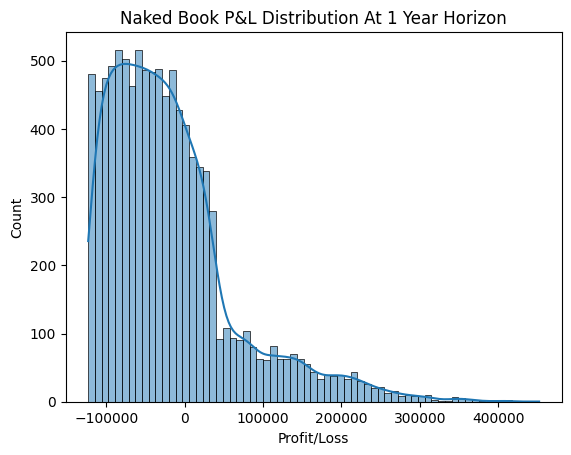

In [ ]:
#Naked P&L Distributions
sns.histplot(Naked_PnL,kde=True)
plt.title('Naked Book P&L Distribution At 1 Year Horizon')
plt.xlabel('Profit/Loss')
plt.ylabel('Count')
plt.show()

DELTA HEDGED P&L: Now we delta-hedge the book on a daily basis to see if we can reduce the risk exposure of holding the book.

In [ ]:
#Delta functions for a single option and entire book
def BS_delta(S, K, T, sigma, option_type, r=r):
  if T<= 0:
    if option_type.lower() == 'call':
      return 1 if S>K else 0
    else:
      return -1 if K>S else 0
  else:
    N_d1 = norm.cdf((np.log(S / K) + ((r + 0.5 * sigma**2) * T)) / (sigma * np.sqrt(T)))
    if option_type.lower() == 'call':
      delta = N_d1
    else:
      delta = N_d1 - 1
    return delta

def book_delta(S, book_S0, book, t, params, initial_position, bump):
  total = 0
  # Sums the total for each option's delta multiplied by the initial position
  for i, (_, row) in enumerate(book.iterrows()):
    sigma = quadratic_vol(t, S, S0, params) + bump
    delta = BS_delta(S, row['Strike'], row['Term (years)'] - t, sigma, row['Type'])
    total += delta * initial_position[i]
  return total

In [ ]:
#Function to simulate delta-hedged book across 1 year, daily rebalances
def delta_hedged_PnL(book, book_S0, params, position, bump, initial_book_value=initial_book_value, drift=drift, dt=dt):
  n_paths = 10000
  T=1
  timesteps=252
  # First hedge to set total delta to zero
  initial_hedge = book_S0 * book_delta(book_S0, book_S0, book, 0, params, position, bump)
  paths = sim_multi_path(book_S0, drift, T, dt, params, n_paths)
  # Initialise arrays
  book_delta_paths = np.zeros((timesteps+1, n_paths))
  book_price_paths = np.zeros((timesteps+1, n_paths))
  bank_account_paths = np.zeros((timesteps+1, n_paths))
  # Initial bank account value
  bank_account_paths[0, :] = initial_book_value - initial_hedge

  # Initialise book deltas so we can access t+1 while iterating t
  for p in range(n_paths):
    book_delta_paths[:, p] = [
        book_delta(paths[t, p], book_S0, book, t*dt, params, position, bump) for t in range(timesteps+1)
        ]

  for t in range(timesteps+1):
    for p in range(n_paths):
      book_value = 0
      # Find book value at time t
      for i, (option, row) in enumerate(book.iterrows()):
        sigma = quadratic_vol(t*dt, paths[t, p], S0, params)

        book_value  += position[i] * black_scholes_price(
          paths[t, p], row['Strike'], row['Term (years)']-(t*dt), r, sigma, row['Type']
        )

      book_price_paths[t, p] = book_value

      if t < timesteps: # Previous period expenditure + P/L from new hedge in current period
       bank_account_paths[t+1, p] = np.exp(r*dt) * bank_account_paths[t, p] + (book_delta_paths[t, p] - book_delta_paths[t+1, p]) * paths[t+1, p]

  # Hedge value
  hedge_value_paths = book_delta_paths * paths

  # Final hedge value (value of stock owned) + final expenditure total + final book value
  Hedged_PnL = [hedge_value_paths[-1, p] + bank_account_paths[-1, p] - book_price_paths[-1, p] for p in range(n_paths)]

  return Hedged_PnL

In [ ]:
#Computationally intensive - 1000 sims takes roughly 11mins
Hedged_PnL = delta_hedged_PnL(book, book_S0, parameter_values, position, 0.001)

In [ ]:
#Delta-hedge results
Hedged_PnL = np.array(Hedged_PnL)
quantile = np.quantile(Hedged_PnL, 0.01)
tail_H = Hedged_PnL[Hedged_PnL < quantile]
# Average across worst 1%
ES_H = -np.mean(tail_H)

print(f"Average delta-hedged P&L: ${round(np.mean(Hedged_PnL), 2)}")
print(f"Delta-hedged VaR (1%):    ${round(quantile, 2)}")
print(f"Delta-hedged VaR (99%):   ${round(np.quantile(Hedged_PnL, 0.99), 2)}")
print(f"Expected Shortfall:       ${round(ES_H, 2)}")
print(f"Hedged P&L Std Dev:       ${round(np.std(Hedged_PnL), 2)}")
print(f"Reduction in Std Dev:     {round((1-(np.std(Hedged_PnL)/np.std(Naked_PnL)))*100, 2)}%")

Average delta-hedged P&L: $19681.92
Delta-hedged VaR (1%):    $-22097.05
Delta-hedged VaR (99%):   $85392.69
Expected Shortfall:       $27316.06
Hedged P&L Std Dev:       $25032.6
Reduction in Std Dev:     69.21%


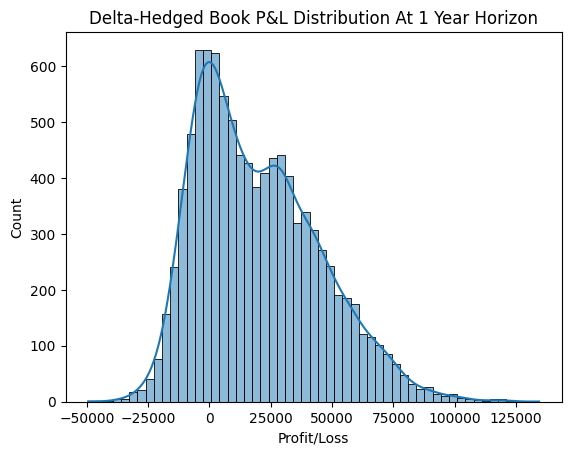

In [ ]:
#Delta-Hedged P&L Distributions
sns.histplot(Hedged_PnL,kde=True)
plt.title('Delta-Hedged Book P&L Distribution At 1 Year Horizon')
plt.xlabel('Profit/Loss')
plt.ylabel('Count')
plt.show()

In [ ]:
print(np.mean(Hedged_PnL))

del Hedged_PnL, Naked_PnL
gc.collect()

19681.922581705272


411